# QS-Net (PyTorch Version)
## Version 2.0

This notebook implements the three QS-Net algorithms, incorporating 3 different algorithms:

1. **Algorithm 1 (MAQT)** shapes Hilbert-space geometry with cross-entropy + intra/inter prototype losses.
2. **Algorithm 2 (CQ-ZDR)** sets a conformal zero-day threshold from known-class calibration data.
3. **Algorithm 3 (Inference)** classifies with a certified radius or flags `ZERO_DAY`.

## Setup

In [1]:
import pennylane as qp
import torch
import torch.nn as nn
from pennylane import numpy as np

import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available?: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA device name: {torch.cuda.get_device_name(0)}")
    print(f"Current CUDA device index: {torch.cuda.current_device()}")

PyTorch version: 2.12.1+cu126
CUDA available?: True
CUDA device name: NVIDIA GeForce GTX 1060
Current CUDA device index: 0


## Helpers

In [3]:
def to_torch_x(x):
    """
    Transform data to 1D torch vector.
    """
    if torch.is_tensor(x):
        return x.detach().clone().to(device=device, dtype=torch.float32).reshape(-1)
    return torch.tensor(x, dtype=torch.float32, device=device)

In [4]:
def to_np_x(x):
    """
    Transform data to 1D numpy vector.
    """
    if torch.is_tensor(x):
        return x.detach().cpu().numpy().reshape(-1)
    return np.asarray(x, dtype=np.float32).reshape(-1)

## Load Dataset: TON IoT

In [5]:
df = pd.read_parquet("data/TON_IoT/quantum/q8_train.parquet")
df

,dst_pkts,protocol,src_pkts,dst_bytes,n_bytes_total,src_bytes,conn_state,duration,label_multiclass,label_binary,label_family
0,0.529836,3.141593,0.556692,1.088846,0.957560,0.758171,3.141593,0.005108,password,1.0,bruteforce_password
1,0.575419,3.141593,0.556692,1.082288,0.987983,0.828671,3.141593,0.017505,injection,1.0,web_injection
2,0.780388,3.141593,0.556692,1.344399,1.152061,0.873394,3.141593,0.535346,ddos,1.0,ddos
3,0.204968,0.836286,0.215358,0.568380,0.594294,0.591666,3.141593,0.001233,password,1.0,bruteforce_password
4,0.529836,3.141593,0.556692,0.901747,0.852190,0.750624,3.141593,0.000617,normal,0.0,benign
...,...,...,...,...,...,...,...,...,...,...,...
60303,0.000000,0.836286,0.430716,0.000000,0.360470,0.747692,3.141593,0.254447,NaN,NaN,NaN
60304,0.614905,3.141593,0.556692,1.165812,1.040995,0.844430,3.141593,0.023131,NaN,NaN,NaN
60305,0.900286,3.141593,1.066925,1.201364,1.140813,1.011379,3.141593,1.428035,NaN,NaN,NaN
60306,0.000000,3.141593,1.490032,0.000000,0.000000,0.000000,3.141593,0.069285,NaN,NaN,NaN


In [6]:
print(df["label_multiclass"].unique())
print()
print(df["label_family"].unique())

<ArrowStringArray>
[ 'password', 'injection',      'ddos',    'normal',       'xss',  'scanning',
  'backdoor',      'mitm',       'dos',         nan]
Length: 10, dtype: str

<ArrowStringArray>
[        'bruteforce_password',               'web_injection',
                        'ddos',                      'benign',
                       'recon', 'backdoor_malware_ransomware',
               'spoofing_mitm',                         'dos',
                           nan]
Length: 9, dtype: str


In [7]:
# check rows if NaN dropped in the label_multiclass column
df[df["label_multiclass"].notna()].copy()

,dst_pkts,protocol,src_pkts,dst_bytes,n_bytes_total,src_bytes,conn_state,duration,label_multiclass,label_binary,label_family
0,0.529836,3.141593,0.556692,1.088846,0.957560,0.758171,3.141593,0.005108,password,1.0,bruteforce_password
1,0.575419,3.141593,0.556692,1.082288,0.987983,0.828671,3.141593,0.017505,injection,1.0,web_injection
2,0.780388,3.141593,0.556692,1.344399,1.152061,0.873394,3.141593,0.535346,ddos,1.0,ddos
3,0.204968,0.836286,0.215358,0.568380,0.594294,0.591666,3.141593,0.001233,password,1.0,bruteforce_password
4,0.529836,3.141593,0.556692,0.901747,0.852190,0.750624,3.141593,0.000617,normal,0.0,benign
...,...,...,...,...,...,...,...,...,...,...,...
41490,0.529836,3.141593,0.604586,1.112493,1.097880,1.022555,3.141593,0.000815,normal,0.0,benign
41491,0.529836,3.141593,0.646074,1.092155,0.994987,0.832071,3.141593,0.232142,normal,0.0,benign
41492,0.885859,3.141593,0.987408,0.988759,1.053146,1.069316,3.141593,1.413128,injection,1.0,web_injection
41493,0.575419,3.141593,0.556692,1.165812,1.037165,0.836487,3.141593,0.038636,normal,0.0,benign


In [8]:
# get labels
class_names = sorted(df["label_multiclass"].dropna().unique())
class_names

['backdoor',
 'ddos',
 'dos',
 'injection',
 'mitm',
 'normal',
 'password',
 'scanning',
 'xss']

In [9]:
def load_split(name, categories):
    df = pd.read_parquet(f"data/TON_IoT/quantum/q8_{name}.parquet")
    df = df[df["label_multiclass"].notna()].copy()

    feature_cols = [c for c in df.columns if not c.startswith("label")]
    X = df[feature_cols].values
    y = pd.Categorical(df["label_multiclass"], categories=categories).codes

    return X, y

In [10]:
def stratified_head(X, y, n, seed=42):
    """
    Take a stratified subset of size n (or all if n >= len(X))
    """
    if n >= len(X):
        return X.copy(), y.copy()
    _, X_sub, _, y_sub = train_test_split(
        X, y, test_size=n, stratify=y, random_state=seed
    )
    return X_sub, y_sub

In [11]:
# load all data
X_train_full, y_train_full = load_split("train", class_names)
X_cal_full, y_cal_full = load_split("calibration", class_names)
X_test_full, y_test_full = load_split("test", class_names)
X_val_full, y_val_full = load_split("val", class_names)

In [12]:
# check shape
[X_train_full.shape, y_train_full.shape], [X_cal_full.shape, y_cal_full.shape], [X_test_full.shape, y_test_full.shape], [X_val_full.shape, y_val_full.shape]

([(41495, 8), (41495,)],
 [(779, 8), (779,)],
 [(785, 8), (785,)],
 [(784, 8), (784,)])

In [13]:
# take subset
X_train, y_train = stratified_head(X_train_full, y_train_full, 20000, seed=42)

X_cal = X_cal_full[:]
y_cal = y_cal_full[:]

X_test = X_test_full[:]
y_test = y_test_full[:]

X_val = X_val_full[:]
y_val = y_val_full[:]

In [14]:
# check shape
[X_train.shape, y_train.shape], [X_cal.shape, y_cal.shape], [X_test.shape, y_test.shape], [X_val.shape, y_val.shape]

([(20000, 8), (20000,)],
 [(779, 8), (779,)],
 [(785, 8), (785,)],
 [(784, 8), (784,)])

In [15]:
num_classes = len(class_names)
num_qubits = X_train.shape[1]

print(f"classes: {class_names}")
print(f"number of classes: {num_classes}")
print(f"number of qubits: {num_qubits}")

classes: ['backdoor', 'ddos', 'dos', 'injection', 'mitm', 'normal', 'password', 'scanning', 'xss']
number of classes: 9
number of qubits: 8


In [16]:
# initialize devices
dev = qp.device("default.mixed", wires=num_qubits)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [17]:
# convert data type
X_train = to_torch_x(X_train)
y_train = to_torch_x(y_train).long()

In [18]:
# check shape
[X_train.shape, y_train.shape], [X_cal.shape, y_cal.shape], [X_test.shape, y_test.shape], [X_val.shape, y_val.shape]

([torch.Size([20000, 8]), torch.Size([20000])],
 [(779, 8), (779,)],
 [(785, 8), (785,)],
 [(784, 8), (784,)])

## Quantum Circuit: Angle Encoding, Data Reuploading, and Adding Noise

$x\xrightarrow[\text{encode}]{\phi(x)}\ket{\psi(x)}\xrightarrow[\text{variational}]{U(\theta)}\ket{\Phi(x)}\xrightarrow{\Lambda_p}\rho(x)$
- $x$: classical data
- $\phi(x)$: `qp.AngleEmbedding()`
- $\ket{\psi(x)}$: quantum state after encoding
- $U(\theta)$: `qp.StronglyEntanglingLayers()`
- $\ket{\Phi(x)}$: quantum state after variational transform
- $\rho(x)=\Lambda_p(\ket{\Phi(x)}\bra{\Phi(x)})$: standard depolarization channel to model NISQ noise

Updates:
- `default.mixed` now returns $\rho$ directly via `qml.density_matrix`
- Add noise with `DepolarizingChannel` (per wire, per layer)
- Replaced (fixed per-observable Pauli traces + softmax) with (Pauli-Z expectation vector + trainable linear head).

In [19]:
# reupload same classical data
num_layers = 2

In [20]:
def initialize_weights(n_layers, n_wires, device):
    """
    Initialize weights for the variational circuit using identity rotations to be barren-plateau-safe.
    """
    shape = qp.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=n_wires)
    return torch.nn.Parameter(torch.zeros(shape, device=device))

In [21]:
# initialize weights
theta = initialize_weights(num_layers, num_qubits, device)
theta.shape

torch.Size([2, 8, 3])

In [22]:
# DEBUG
theta

Parameter containing:
tensor([[[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]]], device='cuda:0', requires_grad=True)

In [23]:
@qp.qnode(dev, interface="torch", diff_method="backprop")
def forward_circuit(x, theta):
    """
    Circuit for encoding, variational, adding noise, and readout.
    """
    for layer in range(num_layers):
        qp.AngleEmbedding(x, wires=range(num_qubits), rotation="Y")
        qp.StronglyEntanglingLayers(theta[layer : layer + 1], wires=range(num_qubits))
        for w in range(num_qubits):
            qp.DepolarizingChannel(noise_rate, wires=w)
    z = [qp.expval(qp.PauliZ(w)) for w in range(num_qubits)]
    rho = qp.density_matrix(wires=range(num_qubits))
    return z, rho

## Measurement

In [24]:
# trainable linear head
classifier_head = nn.Linear(num_qubits, num_classes).to(device)
classifier_head

Linear(in_features=8, out_features=9, bias=True)

## Algo 1: Margin-Aware Quantum Training (MAQT)

### Class Prototypes

For each known class $c$, the average (mixed) quantum state of its training samples becomes the prototype density matrix $\rho_c$, the cluster centre in Hilbert space.

$$
\rho_c = \frac{1}{|D_c|} \sum_{x_i \in D_c} \rho(x_i)
$$

- $D_c$: training samples with label $c$
- $\rho(x_i)$: noisy density matrix for sample $x_i$
- $\rho_c$: mixed state prototype

In [25]:
class PrototypeBank:
    """Running average of rho(x) per class during MAQT minibatches (PyTorch version)"""

    def __init__(self, classes):
        self.classes = sorted(classes)
        self.reset()

    def reset(self):
        self._sums = {c: None for c in self.classes}
        self._counts = {c: 0 for c in self.classes}

    def update(self, label, rho):
        if self._sums[label] is None:
            self._sums[label] = rho.detach().clone()
        else:
            self._sums[label] = self._sums[label] + rho.detach()
        self._counts[label] += 1

    def means(self):
        return {
            c: self._sums[c] / self._counts[c]
            for c in self.classes
            if self._counts[c] > 0
        }

In [26]:
def compute_prototypes(theta, X, y, classes):
    """
    Build final class prototypes by averaging noisy states over training samples one circuit at a time, with no stack. (PyTorch version).
    """
    prototypes = {}
    
    y_labels = to_np_x(y)
    
    with torch.no_grad():        
        for c in classes:
            mask = y_labels == c
            if not mask.any():
                continue

            proto_sum = None
            count = 0

            for x in X[mask]:
                _, rho_x = forward_circuit(to_torch_x(x), theta)

                if proto_sum is None:
                    proto_sum = rho_x.detach().clone()
                else:
                    proto_sum = proto_sum + rho_x.detach()
                count += 1

                del rho_x # free memory immediately

            prototypes[c] = proto_sum / count
            del proto_sum # free memory immediately

    return prototypes

In [27]:
def prototype_summary(prototypes, class_names=None):
    """
    Summarize the prototype density matrices.
    """    
    rows = []
    for c in sorted(prototypes):
        rho_c = prototypes[c]
        name = class_names[c] if class_names is not None else str(c)
        rows.append({
            "class": name,
            "dim": int(rho_c.shape[0]),
            "trace": float(torch.trace(rho_c).real.item()),
        })
    return rows

### Loss Function

$$
L = L_{CE} + \lambda_1 L_{intra} + \lambda_2 L_{inter}
$$

- **$L_{CE}$**: cross-entropy on $\rho(x)$
- **$L_{intra}$**: average infidelity $(1 - fidelity)$ between each sample's state and its class prototype. It describes how far each $\rho(x)$ is from its own class prototype $\rho_c$.
- **$L_{inter}$**: Negative average trace distance between prototypes of different classes.
It describes how close different class prototypes $\rho_c$ and $\rho_{c'}$ are to each other.

In [28]:
def fidelity(rho_a, rho_b):
    """
    Compute the fidelity between two density matrices.
    """
    return qp.math.fidelity(rho_a, rho_b)

In [29]:
def trace_distance(rho_a, rho_b):
    """
    Compute the trace distance between two density matrices.
    """
    return qp.math.trace_distance(rho_a, rho_b)

In [30]:
def maqt_loss(theta, classifier_head, ce_loss_fn, X_batch, y_batch, prototypes, lambda1=0.5, lambda2=0.3):
    """
    MAQT loss function (PyTorch version).
    """
    device = theta.device
    ce = torch.tensor(0.0, device=device)
    intra_terms = {c: [] for c in prototypes}

    # compute the cross-entropy loss
    for x, y_i in zip(X_batch, y_batch):
        x = to_torch_x(x)
        y_int = int(y_i.item()) if torch.is_tensor(y_i) else int(y_i)

        z, rho_x = forward_circuit(x, theta)
        logits = classifier_head(torch.stack(z).float())
        ce = ce + ce_loss_fn(logits.unsqueeze(0), torch.tensor([y_int], device=device, dtype=torch.long))
        proto = prototypes[y_int]
        intra_terms[y_int].append(1.0 - fidelity(rho_x, proto))
        
    l_ce = ce / len(X_batch)

    # compute the intra-class (within-class) fidelity
    l_intra = torch.tensor(0.0, device=device)
    active_classes = [c for c, terms in intra_terms.items() if terms]
    for c in active_classes:
        terms_t = torch.stack(intra_terms[c])
        l_intra = l_intra + terms_t.mean()
    if active_classes:
        l_intra = l_intra / len(active_classes)

    # compute the inter-class (between-class) trace distance
    class_list = sorted(prototypes.keys())
    inter_pairs = []
    for i, c in enumerate(class_list):
        for c_prime in class_list[i + 1:]:
            inter_pairs.append(trace_distance(prototypes[c], prototypes[c_prime]))
    l_inter = -torch.stack(inter_pairs).mean() if inter_pairs else torch.tensor(0.0, device=device)

    # loss function
    loss = l_ce + lambda1 * l_intra + lambda2 * l_inter
    return loss, l_ce, l_intra, l_inter

### Hyperparameters

In [31]:
noise_rate = 0.01
lambda1 = 0.5   # L_intra weight
lambda2 = 0.3   # L_inter weight
epochs = 2
batch_size = 128
lr = 0.05
barren_plateau_var = 1e-6
COMPUTE_GRAD_VAR = True

### Training

Minimizing:
- $L_{CE}$ adjusts $\theta$ for better class predictions.
- $L_{intra}$ pulls each sample toward its class prototype
- $L_{inter}$ pushs different-class prototypes apart (maximize trace distance)

In [32]:
ce_loss = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(list([theta]) + list(classifier_head.parameters()), lr=lr)
prototype_bank = PrototypeBank(range(num_classes))
history = {
    "loss": [],
    "l_ce": [],
    "l_intra": [],
    "l_inter": [],
    "grad_var": [],
    "barren_plateau": [],
}

num_batches = (len(X_train) + batch_size - 1) // batch_size
print(f"training: {len(X_train)} samples, {num_batches} batches/epoch, {epochs} epochs")

for epoch in range(epochs):
    prototype_bank.reset()
    perm = torch.randperm(len(X_train), device=device)
    
    epoch_grad_var = []

    for batch_idx, start in enumerate(range(0, len(perm), batch_size)):
        print(f"epoch {epoch + 1} batch {batch_idx}/{num_batches - 1}", flush=True)

        idx = perm[start : start + batch_size]
        X_batch, y_batch = X_train[idx], y_train[idx]

        # running prototype update for classes present in this batch
        for x, label in zip(X_batch, y_batch):
            _, rho_x = forward_circuit(x, theta)
            prototype_bank.update(int(label.item()), rho_x)
        batch_prototypes = prototype_bank.means()

        # compute loss
        loss, L_CE, L_intra, L_inter = maqt_loss(
            theta, classifier_head, ce_loss, X_batch, y_batch, batch_prototypes,
            lambda1=lambda1, lambda2=lambda2,
        )

        # clear old grads
        optimizer.zero_grad()

        # compute new grads
        loss.backward()

        # compute gradient variance
        if COMPUTE_GRAD_VAR and theta.grad is not None:
            epoch_grad_var.append(float(theta.grad.var().item()))

        # update weights
        optimizer.step()

    mean_gvar = float(np.mean(epoch_grad_var)) if epoch_grad_var else 0.0
    plateau = mean_gvar < barren_plateau_var

    history["loss"].append(float(loss.item()))
    history["l_ce"].append(float(L_CE.item()))
    history["l_intra"].append(float(L_intra.item()))
    history["l_inter"].append(float(L_inter.item()))
    history["grad_var"].append(mean_gvar)
    history["barren_plateau"].append(plateau)

    print(
        f"epoch {epoch + 1:02d}/{epochs} | loss={loss.item():.4f} | "
        f"l_ce={L_CE.item():.4f} | l_intra={L_intra.item():.4f} | l_inter={L_inter.item():.4f} | "
        f"grad_var={mean_gvar:.2e} | barren_plateau={plateau}"
    )

theta_star = theta
prototypes = compute_prototypes(theta_star, X_train, y_train, range(num_classes)) # recompute final prototypes over all of D

training: 20000 samples, 157 batches/epoch, 2 epochs
epoch 1 batch 0/156
epoch 1 batch 1/156
epoch 1 batch 2/156
epoch 1 batch 3/156
epoch 1 batch 4/156
epoch 1 batch 5/156
epoch 1 batch 6/156
epoch 1 batch 7/156
epoch 1 batch 8/156
epoch 1 batch 9/156
epoch 1 batch 10/156
epoch 1 batch 11/156
epoch 1 batch 12/156
epoch 1 batch 13/156
epoch 1 batch 14/156
epoch 1 batch 15/156
epoch 1 batch 16/156
epoch 1 batch 17/156
epoch 1 batch 18/156
epoch 1 batch 19/156
epoch 1 batch 20/156
epoch 1 batch 21/156
epoch 1 batch 22/156
epoch 1 batch 23/156
epoch 1 batch 24/156
epoch 1 batch 25/156
epoch 1 batch 26/156
epoch 1 batch 27/156
epoch 1 batch 28/156
epoch 1 batch 29/156
epoch 1 batch 30/156
epoch 1 batch 31/156
epoch 1 batch 32/156
epoch 1 batch 33/156
epoch 1 batch 34/156
epoch 1 batch 35/156
epoch 1 batch 36/156
epoch 1 batch 37/156
epoch 1 batch 38/156
epoch 1 batch 39/156
epoch 1 batch 40/156
epoch 1 batch 41/156
epoch 1 batch 42/156
epoch 1 batch 43/156
epoch 1 batch 44/156
epoch 1 batc

In [33]:
# DEBUG
theta_star

Parameter containing:
tensor([[[ 0.0000, -0.2792,  0.0000],
         [ 0.0000, -0.4824,  0.0000],
         [ 0.0000,  1.2461,  0.0000],
         [ 0.0000,  0.7265,  0.0000],
         [ 0.0000, -0.4790,  0.0000],
         [ 0.0000,  0.2408,  0.0000],
         [ 0.0000,  0.1399,  0.0000],
         [ 0.0000,  1.1604,  0.0000]],

        [[ 0.0000,  0.6440,  0.0000],
         [ 0.0000,  0.2541,  0.0000],
         [ 0.0000,  0.7277,  0.0000],
         [ 0.0000,  0.1578,  0.0000],
         [ 0.0000,  0.1137,  0.0000],
         [ 0.0000, -0.0702,  0.0000],
         [ 0.0000, -0.0477,  0.0000],
         [ 0.0000,  0.6221,  0.0000]]], device='cuda:0', requires_grad=True)

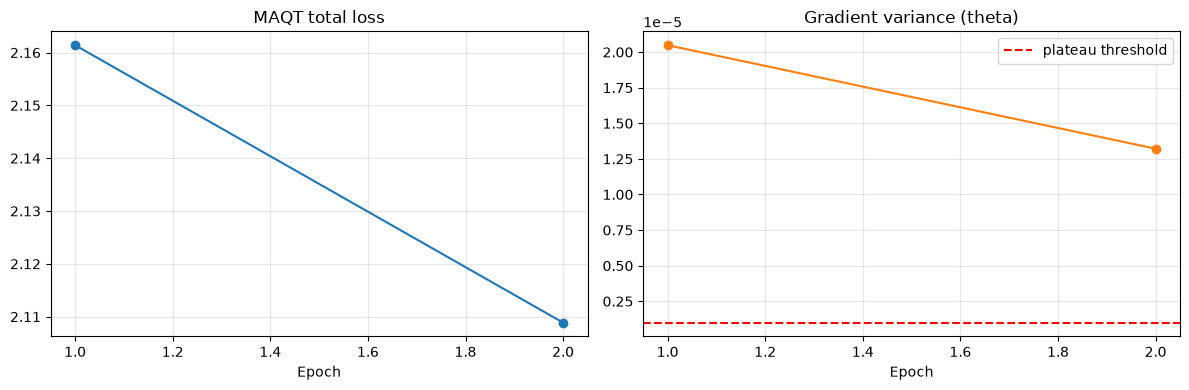

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, epochs + 1), history["loss"], marker="o")
axes[0].set_title("MAQT total loss")
axes[0].set_xlabel("Epoch")
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, epochs + 1), history["grad_var"], marker="o", color="tab:orange")
axes[1].axhline(barren_plateau_var, color="red", linestyle="--", label="plateau threshold")
axes[1].set_title("Gradient variance (theta)")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Algo 2: Conformal Zero-Day Threshold Calibration (CQ-ZDR)

Nonconformity score: $s_i = 1 - \max_c F(\rho(x_i), \rho_c)$.

Split-conformal threshold: $q = s_{(k)}$ with $k = \lceil (1 - \alpha)(n + 1) \rceil$.

In [35]:
def nonconformity_score(x, theta, prototypes):
    """
    Nonconformity score (PyTorch version).
    """
    with torch.no_grad():
        _, rho_x = forward_circuit(to_torch_x(x), theta)
        fids = [fidelity(rho_x, prototypes[c]) for c in sorted(prototypes)]
        return float((1.0 - torch.max(torch.stack(fids))).item())

In [36]:
def calibrate_threshold(theta, X_cal, prototypes, alpha=0.05):
    """
    Calibrate the threshold.
    """
    scores = np.array([nonconformity_score(x, theta, prototypes) for x in X_cal])
    scores_sorted = np.sort(scores)
    n = len(scores_sorted)
    k = int(np.ceil((1.0 - alpha) * (n + 1))) - 1   # convert 1-based index to 0-based
    k = min(max(k, 0), n - 1)   # clip to valid index
    q = float(scores_sorted[k])
    return q, scores_sorted

In [37]:
alpha = 0.05
q, scores_sorted = calibrate_threshold(theta_star, X_cal, prototypes, alpha=alpha)
print(f"conformal threshold q = {q:.4f} (alpha={alpha}, n_cal={len(X_cal)})")

conformal threshold q = 0.7822 (alpha=0.05, n_cal=779)


## Algo 3: Unified Inference with Disentangled Rejection

At test time, one pass produces either
- a class label with a certified robustness radius $\rightarrow$ `(label, certified_radius)`, or
- a zero-day flag $\rightarrow$ `(ZERO_DAY, 0)`.

In [38]:
def estimate_lipschitz(X, theta, n_probe=30, delta=0.05):
    """
    Estimate Lipschitz constant from data.
    """
    X_np = to_np_x(X)
    indices = np.random.choice(len(X_np), min(n_probe, len(X)), replace=False)
    ratios = []
    
    with torch.no_grad():
        for i in indices:
            x = to_torch_x(to_np_x(X_np[i]))            
            x_pert = x + delta * torch.randn_like(x)
            _, r1 = forward_circuit(x, theta)
            _, r2 = forward_circuit(x_pert, theta)
            ratios.append(trace_distance(r1, r2) / delta)

    return float(torch.max(torch.stack(ratios)).item())

L_phi = estimate_lipschitz(X_train, theta_star)
print(f"estimated L_phi = {L_phi:.4f}")

estimated L_phi = 1.2880


In [39]:
L_phi = 1.288 # encoder Lipschitz constant # -- EDIT HERE --
Cf = 1.0    # contraction constant from Proposition 1
ZERO_DAY = -1

In [40]:
def qsnet_infer(x, theta, prototypes, q, p=noise_rate, L_phi=L_phi, Cf=Cf):
    """
    Unified inference with disentangled rejection.
    """
    with torch.no_grad():
        _, rho_x = forward_circuit(to_torch_x(x), theta)
        class_ids = sorted(prototypes.keys())
        f_map = {c: float(fidelity(rho_x, prototypes[c]).item()) for c in class_ids}
        f_vals = [f_map[c] for c in class_ids]

    c_star = class_ids[int(np.argmax(f_vals))]
    s = 1.0 - f_map[c_star]

    if s > q:
        return ZERO_DAY, 0.0, s, f_map

    sorted_f = sorted(f_vals, reverse=True)
    margin = sorted_f[0] - sorted_f[1] if len(sorted_f) > 1 else sorted_f[0]
    radius = margin / (2.0 * (1.0 - p) * L_phi * Cf)

    return c_star, float(radius), s, f_map

## Evaluation

In [41]:
def predict_batch(X, theta, prototypes, q):
    """
    Make batch predictions.
    """
    labels, radii, scores = [], [], []
    for x in X:
        label, radius, score, _ = qsnet_infer(x, theta, prototypes, q)
        labels.append(label)
        radii.append(radius)
        scores.append(score)
    return np.array(labels), np.array(radii), np.array(scores)

## Evaluation on Known Test Samples

known-sample accuracy (non-rejected): 0.089
rejection rate on test: 0.039
mean certified radius (accepted): 0.0020

classification report (accepted predictions only):
              precision    recall  f1-score   support

    backdoor       0.01      0.25      0.01         4
        ddos       0.00      0.00      0.00        92
         dos       0.05      0.32      0.09        47
   injection       0.00      0.00      0.00       160
        mitm       0.00      0.00      0.00         6
      normal       0.25      0.26      0.25       195
    password       0.00      0.00      0.00       139
    scanning       0.09      0.03      0.05        32
         xss       0.00      0.00      0.00        79

    accuracy                           0.09       754
   macro avg       0.04      0.10      0.04       754
weighted avg       0.07      0.09      0.07       754



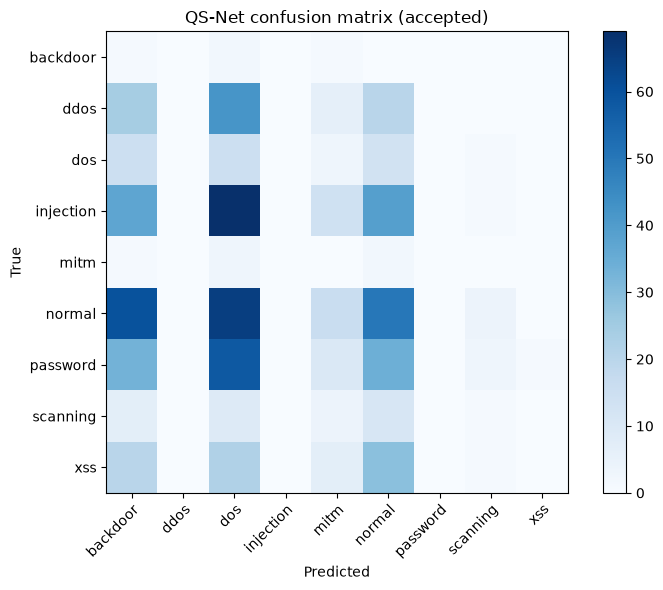

In [42]:
y_pred, radii, novelty_scores = predict_batch(X_test, theta_star, prototypes, q)

known_mask = y_pred != ZERO_DAY
label_ids = list(range(num_classes))

known_acc = np.mean(y_pred[known_mask] == y_test[known_mask]) if known_mask.any() else 0.0
reject_rate = 1.0 - known_mask.mean()

print(f"known-sample accuracy (non-rejected): {known_acc:.3f}")
print(f"rejection rate on test: {reject_rate:.3f}")
print(f"mean certified radius (accepted): {radii[known_mask].mean():.4f}")

if known_mask.any():
    print("\nclassification report (accepted predictions only):")
    print(classification_report(
        y_test[known_mask], y_pred[known_mask],
        labels=label_ids, target_names=class_names, zero_division=0,
    ))

    cm = confusion_matrix(y_test[known_mask], y_pred[known_mask], labels=label_ids)
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        xlabel="Predicted",
        ylabel="True",
        title="QS-Net confusion matrix (accepted)",
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    plt.tight_layout()
    plt.show()

In [43]:
# known-class accuracy using the trained CE readout, not fidelity inference or conformal rejection
with torch.no_grad():
    preds_ce = []
    for x in X_test:
        z, _ = forward_circuit(to_torch_x(x), theta_star)
        z = z if torch.is_tensor(z) else torch.stack(z)
        pred = classifier_head(z.float()).argmax().item()
        preds_ce.append(pred)

print("CE-head accuracy:", np.mean(np.array(preds_ce) == y_test))
print(classification_report(y_test, np.array(preds_ce), labels=label_ids, target_names=class_names, zero_division=0))

CE-head accuracy: 0.2624203821656051
              precision    recall  f1-score   support

    backdoor       0.00      0.00      0.00         5
        ddos       0.00      0.00      0.00        93
         dos       0.00      0.00      0.00        48
   injection       0.00      0.00      0.00       167
        mitm       0.00      0.00      0.00         6
      normal       0.26      1.00      0.42       206
    password       0.00      0.00      0.00       142
    scanning       0.00      0.00      0.00        35
         xss       0.00      0.00      0.00        83

    accuracy                           0.26       785
   macro avg       0.03      0.11      0.05       785
weighted avg       0.07      0.26      0.11       785



## Zero-Day Evaluation

In [44]:
df_zero = pd.read_parquet("data/TON_IoT/quantum/q8_zeroday.parquet")
df_zero

,dst_pkts,protocol,src_pkts,dst_bytes,n_bytes_total,src_bytes,conn_state,duration,label_multiclass,label_binary,label_family
0,0.204968,3.141593,0.0,0.0,0.0,0.0,0.326077,0.0,NaN,NaN,NaN


In [45]:
feature_cols = [c for c in df_zero.columns if not c.startswith("label")]

X_zero = df_zero[feature_cols].values.astype(np.float32)
y_zero = df_zero["label_family"].values

In [46]:
y_zero_pred, radii_zero, scores_zero = predict_batch(X_zero, theta_star, prototypes, q)

detection_rate = (y_zero_pred == ZERO_DAY).mean()

print(f"detected as ZERO_DAY: {detected.sum()} / {len(X_zero)} ({detection_rate:.1%})")
print(f"incorrectly accepted: {(~detected).sum()}")
print(f"mean novelty score: {scores_zero.mean():.4f} | threshold q: {q:.4f}")

if (~detected).any():
    for i in np.where(~detected)[0]:
        print(f"  accepted idx={i} true={y_zero[i]} pred={class_names[y_zero_pred[i]]} score={scores_zero[i]:.4f}")

detected as ZERO_DAY: 0 / 1 (0.0%)
incorrectly accepted: 1
mean novelty score: 0.6293 | threshold q: 0.7822
  accepted idx=0 true=nan pred=normal score=0.6293


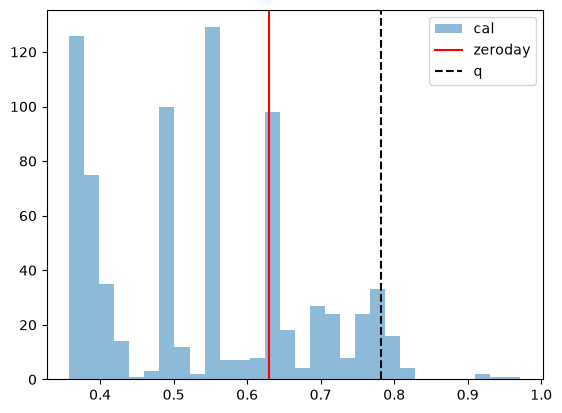

In [47]:
plt.hist(scores_sorted, bins=30, alpha=0.5, label="cal")
plt.axvline(scores_zero[0], color="r", label="zeroday")
plt.axvline(q, color="k", linestyle="--", label="q")
plt.legend(); plt.show()

## References

- Importing PennyLane as qp: https://pennylane.ai/blog/2026/03/import-pennylane-as-qp-growing-beyond-just-qml
- Encoding data in angles: https://docs.pennylane.ai/en/stable/code/api/pennylane.AngleEmbedding.html
- Data reuploading: https://pennylane.ai/demos/tutorial_data_reuploading_classifier
- Strong entangling layers: https://docs.pennylane.ai/en/stable/code/api/pennylane.StronglyEntanglingLayers.html
- Standard depolarization: https://profmcruz.wordpress.com/wp-content/uploads/2017/08/quantum-computation-and-quantum-information-nielsen-chuang.pdf, p-378.
- Standard depolarization in PennyLane: https://docs.pennylane.ai/en/stable/code/api/pennylane.DepolarizingChannel.html